#**Synthesizing Hand-written Digits with a GAN**

We are going to train a generative adversarial network that can produce synthetic hand-written digits. The network will be trained using the MNIST dataset, and will learn to produce new digit photos based on an input class label!

# *Imports and Data*

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import keras
from keras.utils import plot_model
from keras.layers import (Input, Embedding, Dense, Reshape, Concatenate,
                          LeakyReLU, Flatten, Dropout, Conv2D, Conv2DTranspose, BatchNormalization)
from keras import Model

# Load and preprocess MNIST - note, load_data() returns train and test set tuples, and the _ means throw away the latter.
(trainX, trainY), _ = mnist.load_data()

# Expand the dimensionality of the tensor to add a single new dimension, i.e., 'color channel' (grayscale)
# And convert values from integers to decimals (floats)
trainX = np.expand_dims(trainX, axis=-1).astype('float32')

# We are going to center the pixel values around 0.
trainX = (trainX - 127.5) / 127.5
dataset = [trainX, trainY]

Remember our data is images of hand-written digits, paired with their labels (integers).

5


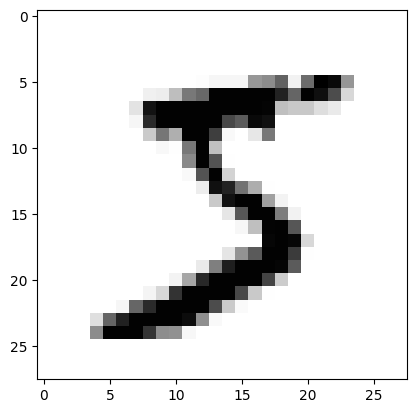

In [2]:
# Print first label
print(trainY[0])

# Plot first image
plt.imshow(trainX[0, :, :, 0], cmap='Grays')

#*Define our Discriminator*

We are going to define the discriminator as its own standalone network for two reasons. First, we need to compile it with its own loss function. Second, we are going to alternative between training the discriminator and training the generator. The way we implement the training steps is different.

In [99]:

def define_discriminator(n_classes=10):
  # Input 1: the class label (which digit, 0-9)
  label_input = Input(shape=(1,), name="discriminator_integer_input", dtype="int32")
  em = Embedding(n_classes, 50)(label_input)       # turn label into a 50-dim vector
  em = Dense(28 * 28)(em)                           # project to image size
  em = Reshape((28, 28, 1))(em)                     # reshape to a 28x28 "channel"

  # Input 2: the image (real or fake)
  image_input = Input(shape=(28, 28, 1), name="discriminator_image_input")
  noisy_image = keras.layers.GaussianNoise(0.1)(image_input)

  # Stack the image and the conditional integer (label) channel together
  x = Concatenate()([noisy_image, em])

  # Two convolutional layers that downsample the image
  x = Conv2D(128, (3,3), strides=(2,2), padding='same')(x)

  # GANs have very unstable training, so dead neurons arise easily.
  # LeakyReLU activtions are important to avoid this happening.
  # 0.2 is the output for the negative domain of input
  x = LeakyReLU(0.2)(x)
  x = Dropout(0.5)(x)

  x = Conv2D(128, (3,3), strides=(2,2), padding='same')(x)
  x = LeakyReLU(0.2)(x)

  # Flatten the feature maps into a prediction
  x = Flatten()(x)
  x = Dropout(0.5)(x)

  # real vs fake probability
  out = Dense(1, activation='sigmoid', name="discriminator_prediction")(x)

  model = Model([image_input, label_input], out)
  adam = tf.keras.optimizers.Adam(learning_rate=0.00002, beta_1=0.5)
  model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
  return model

discriminator = define_discriminator()

#*Define Generator Model*

In [100]:
LATENT_DIM = 100  # size of the random noise vector fed to the generator

def define_generator(latent_dim=LATENT_DIM, n_classes=10):
  # Input 1: integer label, i.e., what kind of number are we drawing?
  label_input = Input(shape=(1,), name="generator_integer_input")
  em = Embedding(n_classes, 50)(label_input)
  em = Dense(7 * 7)(em)
  em = Reshape((7, 7, 1))(em)

  # Input 2: random noise vector - seed data to spit out a random new integer of type 'label_input'
  noise_input = Input(shape=(latent_dim,),name="generator_noise_input")
  x = Dense(128 * 7 * 7)(noise_input)
  x = BatchNormalization()(x)
  x = LeakyReLU(0.2)(x)

  # Convert the vector to 128, 7x7 feature maps
  x = Reshape((7, 7, 128))(x)

  # Merge noise feature maps and the integer label
  x = Concatenate()([x, em])

  # Upsample feature maps from 7x7 -> 14x14
  x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same')(x)
  x = BatchNormalization()(x)
  x = LeakyReLU(0.2)(x)

  # Upsample feature maps from 14x14 -> 28x28
  x = Conv2DTranspose(128, kernel_size=4, strides=2, padding='same')(x)
  x = BatchNormalization()(x)
  x = LeakyReLU(0.2)(x)

  #Take everything to a single channel
  out = Conv2D(1, kernel_size=7, activation='tanh', padding='same')(x)  # single-channel output

  model = Model([noise_input, label_input], out)
  return model

# Notice we aren't compiling the generator... it doesn't get its own loss.
# Everything will be based on the discriminator's predictions and associated loss.
generator = define_generator()

#*Now, stitch the two networks together to create our GAN structure*

We will have two models in memory. They share layers (the discriminator layers appear in both). These are not copies of the same model; they are literally the same model layers in memory, with the same weights. When we compile two models in memory, and we set 'trainable = False' for the discriminator's layers in one, but not the other, these two models will take different actions on the discriminator weights. One will update the weights in training (the discriminator model) the other will ignore those weights (the GAN that embeds the discriminator).

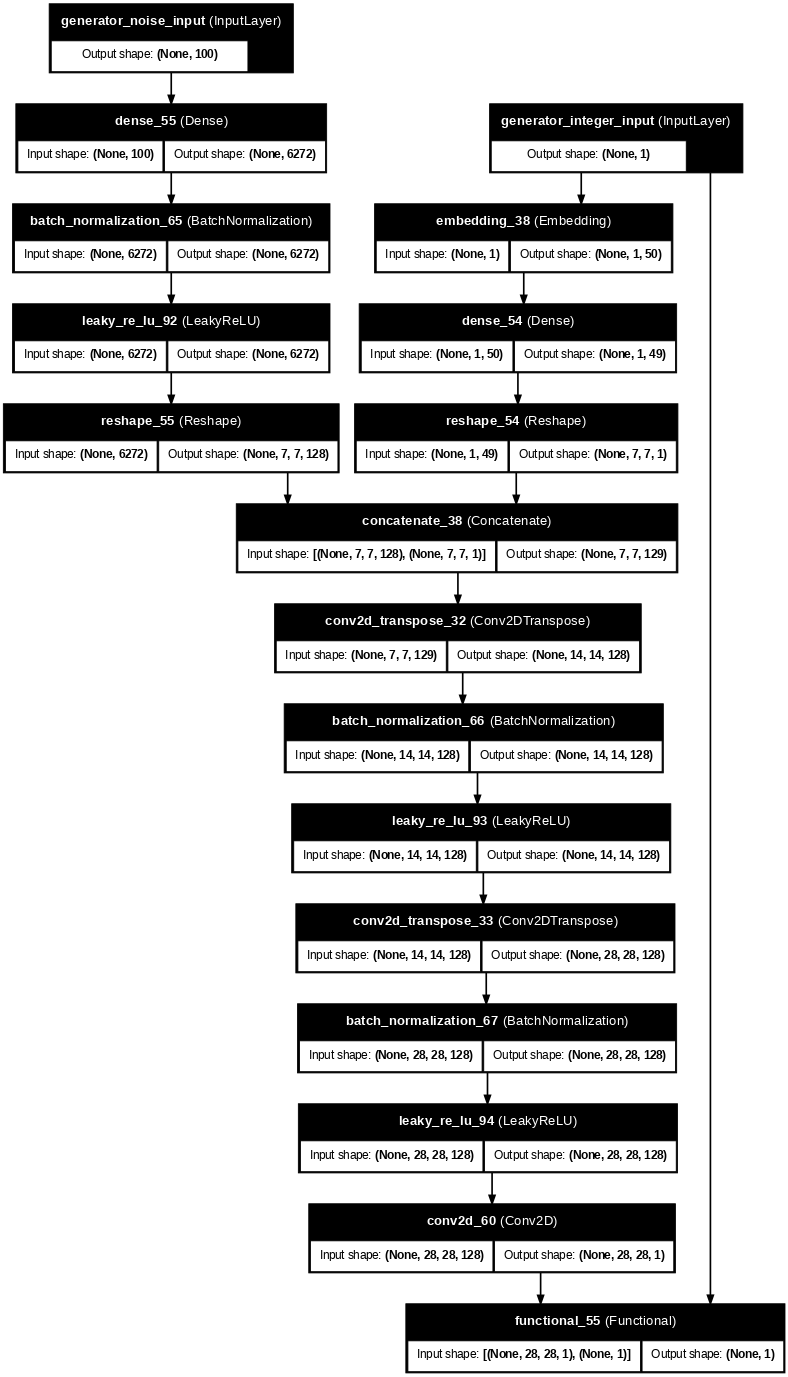

In [101]:
def define_gan(generator, discriminator):

  ### FIRST THE GENERATOR

  # generator.input is a pointer to the [noise_input, label_input] defined above in the last block.
  # We are just pulling the two layers apart here to be able to pass them on in different ways downstream.
  noise_input, label_input = generator.input

  # We get the random image our generator produces
  fake_image = generator.output

  ### THEN THE DISCRIMINATOR

  # The final output layer will be what the discriminator produces when you pass it the generator's synthetic
  # and the label of what it's trying to produce.
  gan_output = discriminator([fake_image, label_input])

  # Finally, we stick the whole GAN together... generator input with label through to discriminator output.
  model = Model([noise_input, label_input], gan_output)

  # Compile the whole thing
  model.compile(loss='binary_crossentropy', optimizer="adam")
  return model

gan = define_gan(generator, discriminator)

# Note: that 'functional' block at the end is the whole discriminator network / model.
plot_model(gan, show_shapes=True, show_layer_names=True, dpi=60)

# *Helper Functions*

We are defining a couple of helper functions to load real images and fake images. Real images are just sampled from training data. Fake images are generated from the generator, using its weights at any given point in time when we call the helper.

In [96]:
def get_real_samples(dataset, n):
  """Pick n random real images and labels from the dataset."""
  images, labels = dataset
  idx = np.random.randint(0, images.shape[0], n)

  # We return np.ones because these are labels indicating a set of 'real' images to the discriminator.
  return [images[idx], labels[idx]], np.ones((n, 1))

def get_fake_samples(generator, n):
  """Generate n fake images by feeding random noise + random labels to the generator."""
  noise = np.random.randn(n, LATENT_DIM)
  labels = np.random.randint(0, 10, n)
  images = generator.predict([noise, labels], verbose=0)

  # We return np.zeros because these are labels indicating a set of 'fake' images to the discriminator.
  return [images, labels], np.zeros((n, 1))

# *Training Loop*

Training the discriminator is easy to follow. We give it half a batch of real images, and half a batch of generated images, along with indicators of which are real and which are fake.

Next, we train the generator, inside the bigger 'GAN' network (which also includes the frozen discriminator).

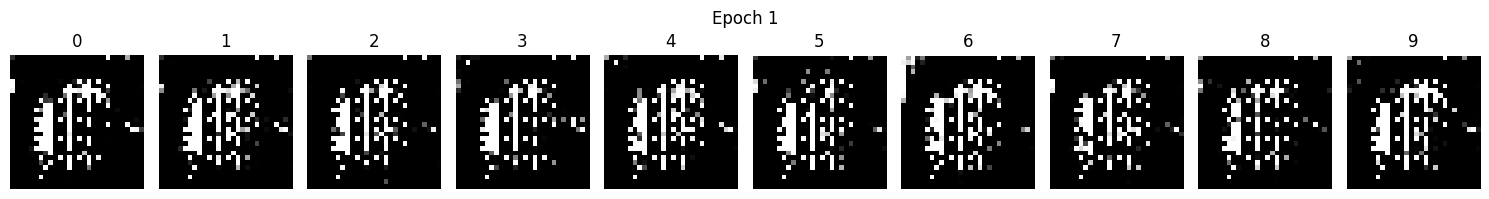

Epoch 1/100  |  D_real 0.584  D_fake 0.814  G 0.650


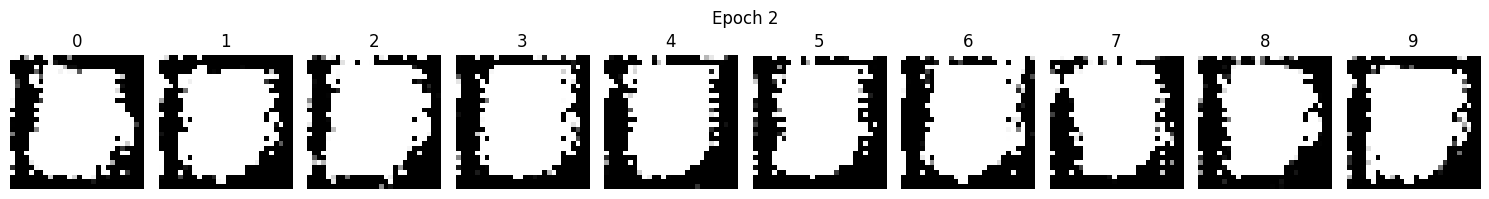

Epoch 2/100  |  D_real 0.620  D_fake 1.166  G 0.700


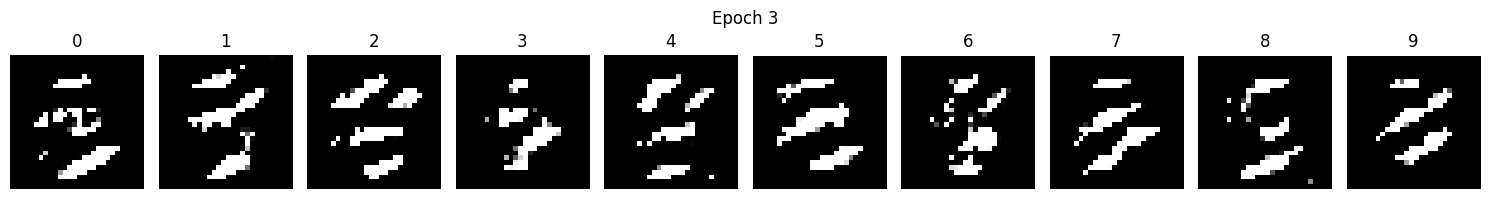

Epoch 3/100  |  D_real 0.704  D_fake 0.720  G 0.689


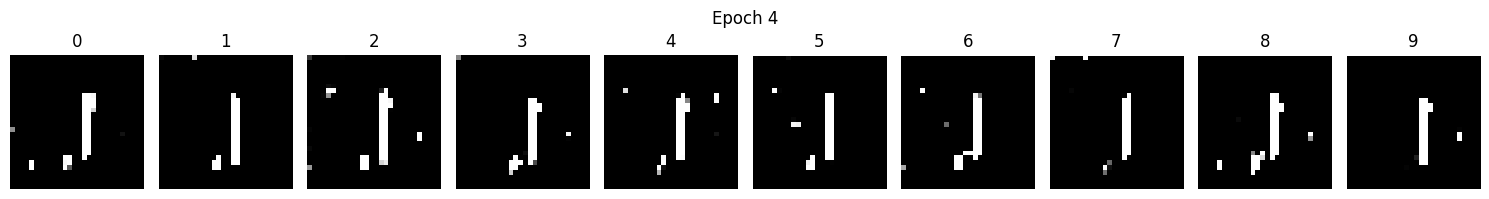

Epoch 4/100  |  D_real 0.695  D_fake 0.704  G 0.698


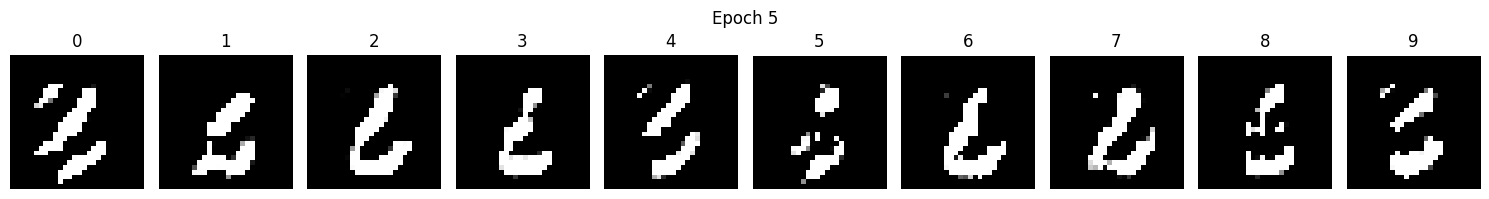

Epoch 5/100  |  D_real 0.692  D_fake 0.659  G 0.707


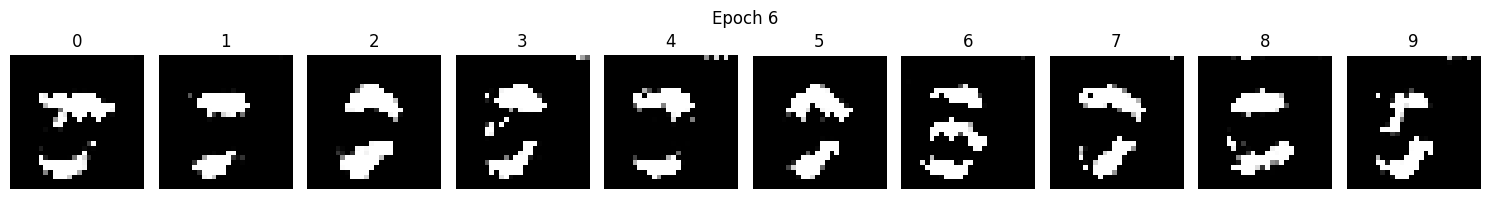

Epoch 6/100  |  D_real 0.660  D_fake 0.636  G 0.715


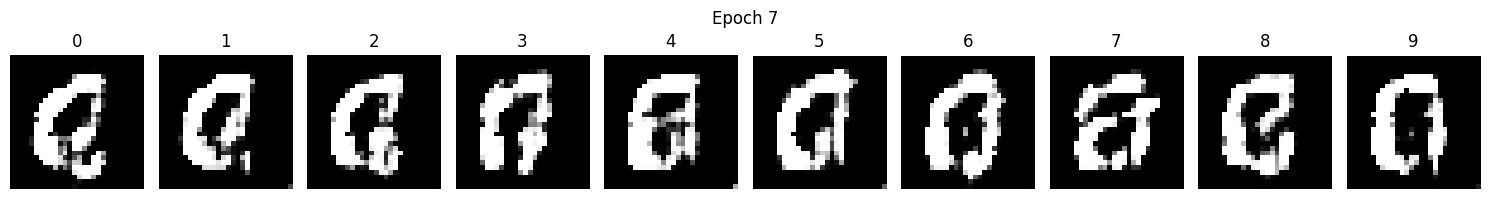

Epoch 7/100  |  D_real 0.694  D_fake 0.810  G 0.720


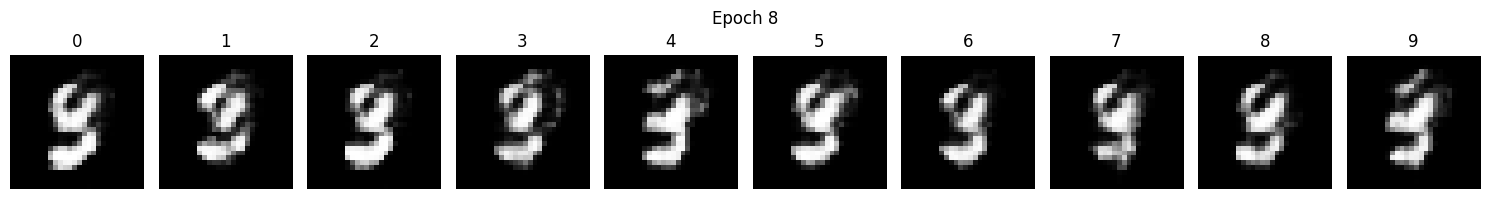

Epoch 8/100  |  D_real 0.672  D_fake 0.726  G 0.705


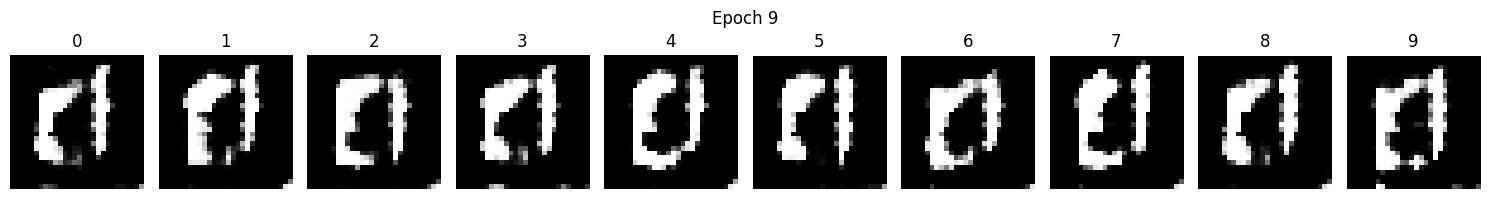

Epoch 9/100  |  D_real 0.673  D_fake 0.678  G 0.706


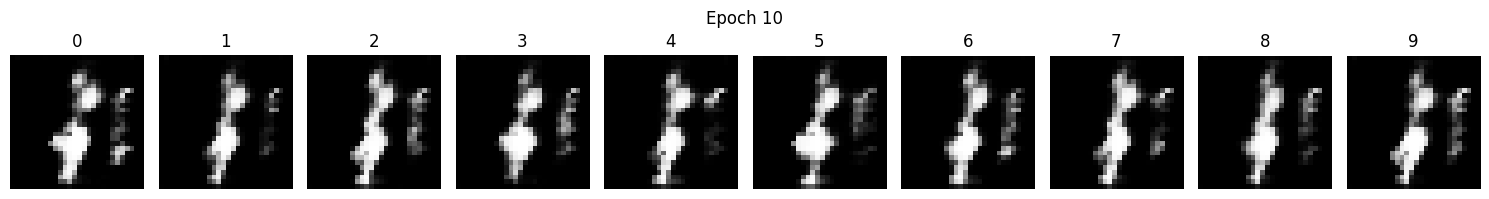

Epoch 10/100  |  D_real 0.668  D_fake 0.643  G 0.705


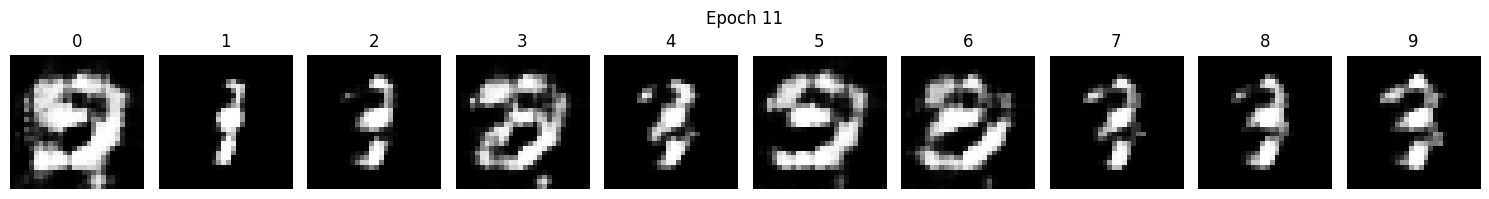

Epoch 11/100  |  D_real 0.676  D_fake 0.722  G 0.703


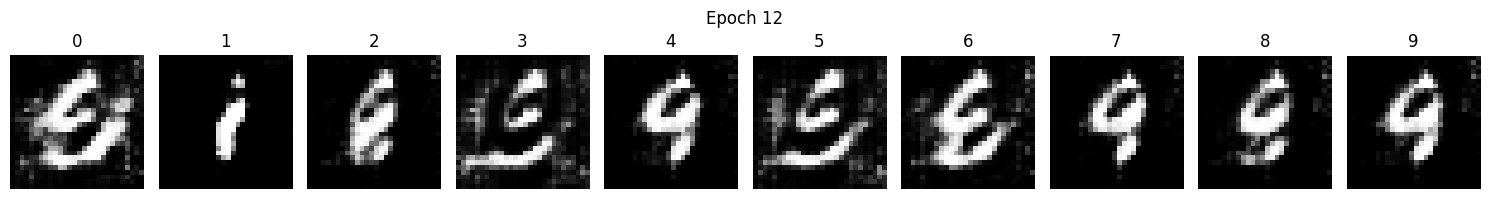

Epoch 12/100  |  D_real 0.688  D_fake 0.714  G 0.699


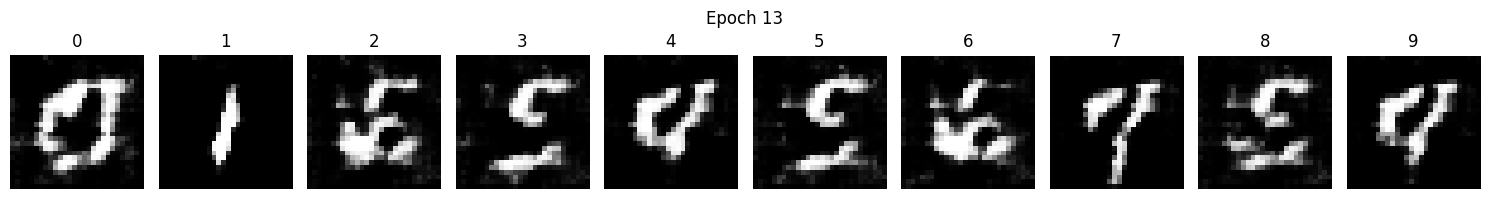

Epoch 13/100  |  D_real 0.700  D_fake 0.765  G 0.696


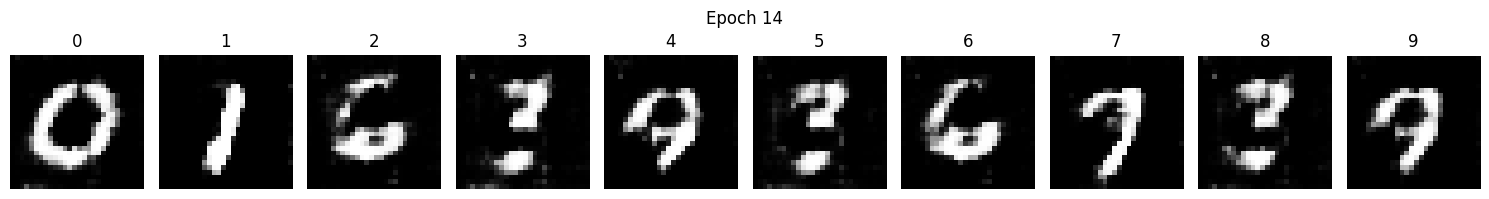

Epoch 14/100  |  D_real 0.672  D_fake 0.717  G 0.693


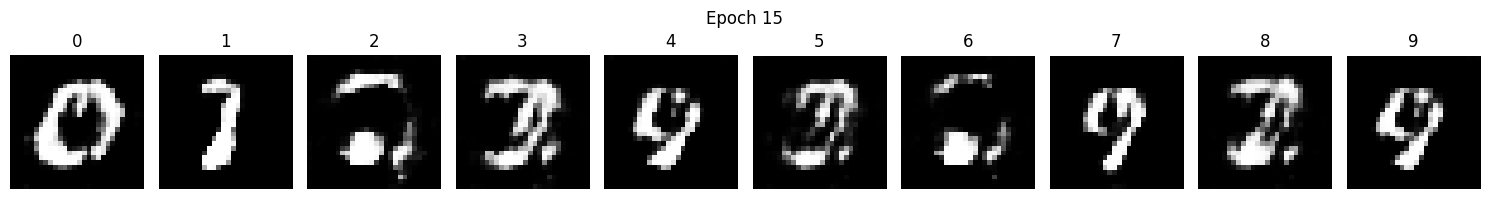

Epoch 15/100  |  D_real 0.702  D_fake 0.708  G 0.693


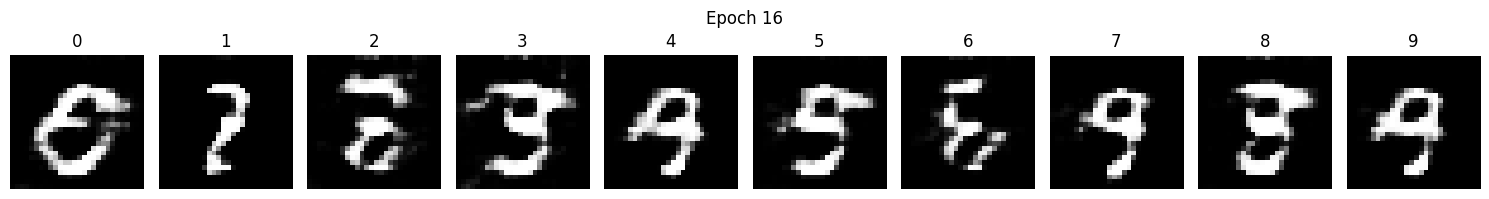

Epoch 16/100  |  D_real 0.678  D_fake 0.715  G 0.692


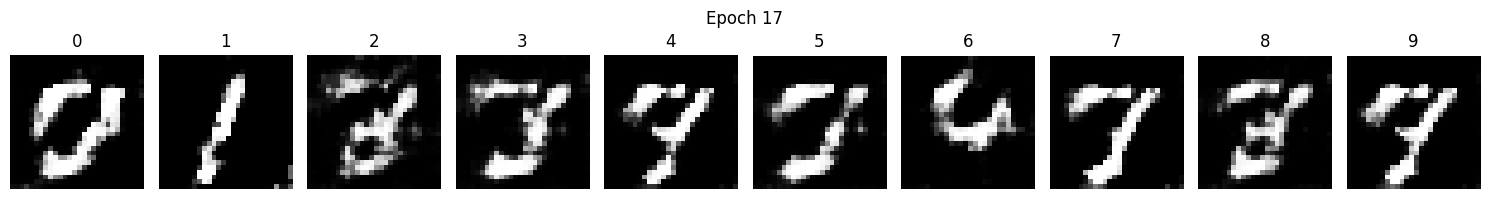

Epoch 17/100  |  D_real 0.709  D_fake 0.680  G 0.692


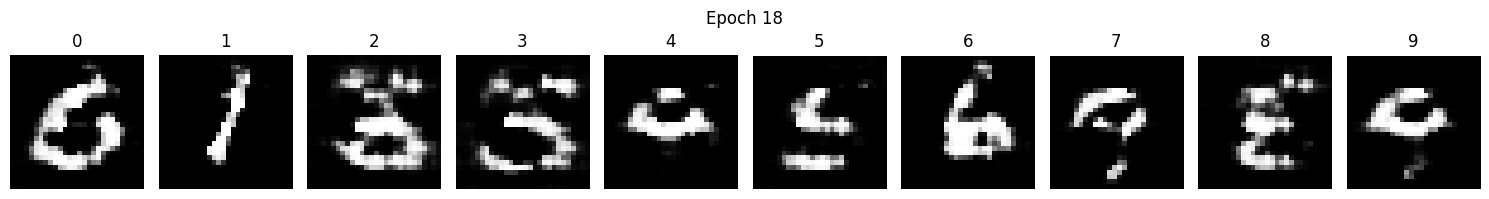

Epoch 18/100  |  D_real 0.669  D_fake 0.703  G 0.692


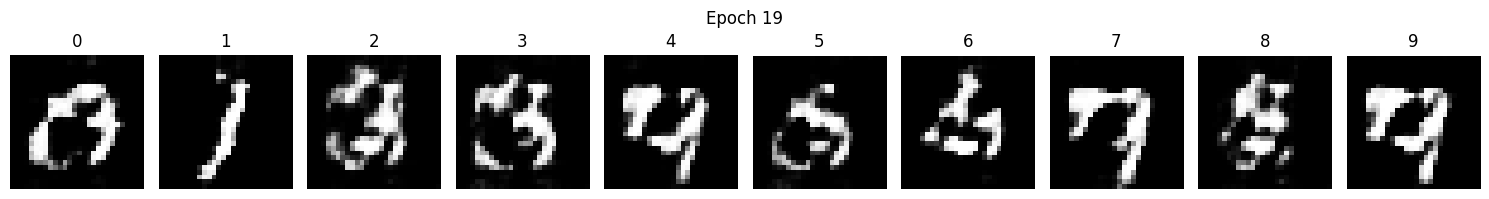

Epoch 19/100  |  D_real 0.681  D_fake 0.697  G 0.692


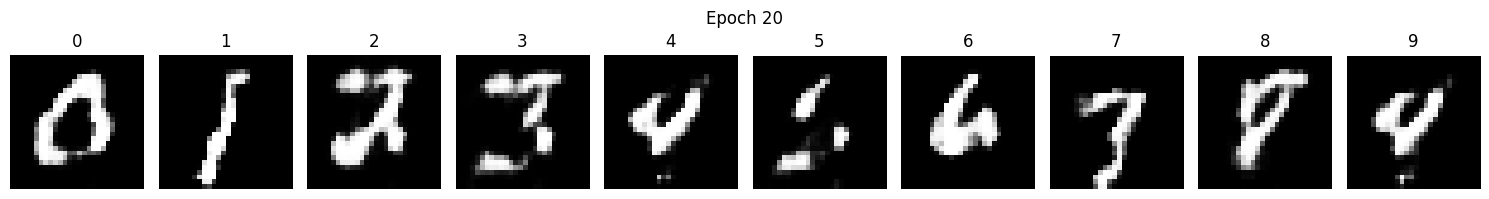

Epoch 20/100  |  D_real 0.689  D_fake 0.710  G 0.693


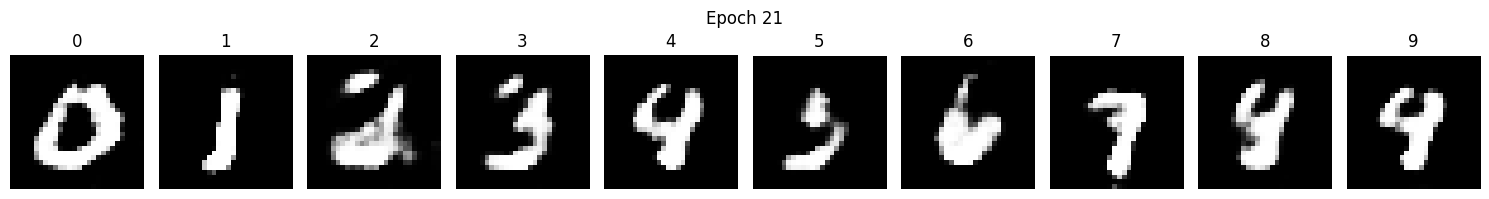

Epoch 21/100  |  D_real 0.674  D_fake 0.704  G 0.693


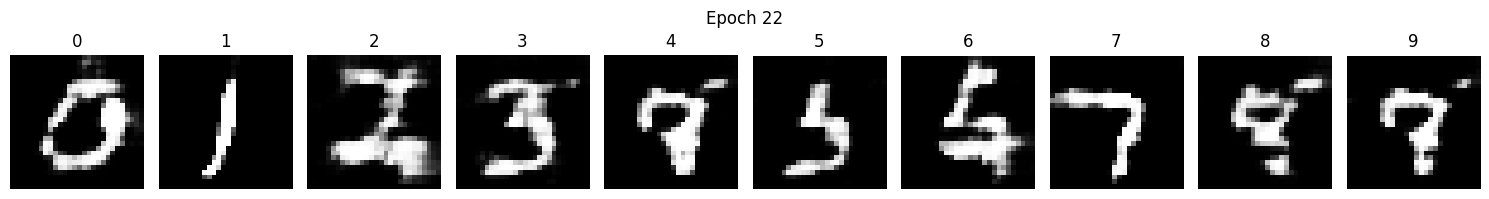

Epoch 22/100  |  D_real 0.684  D_fake 0.697  G 0.693


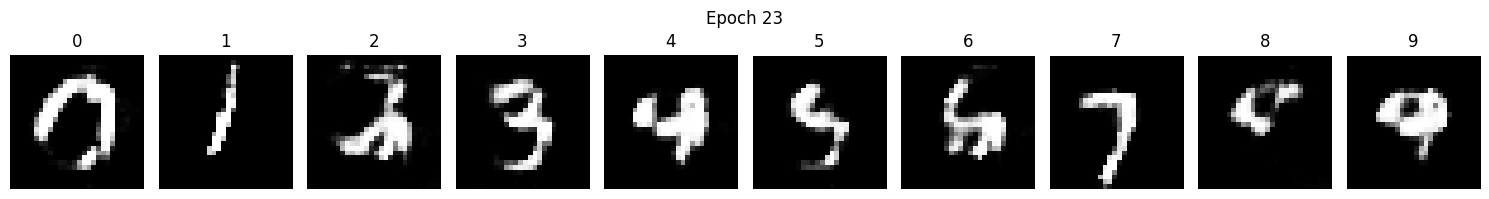

Epoch 23/100  |  D_real 0.689  D_fake 0.691  G 0.692


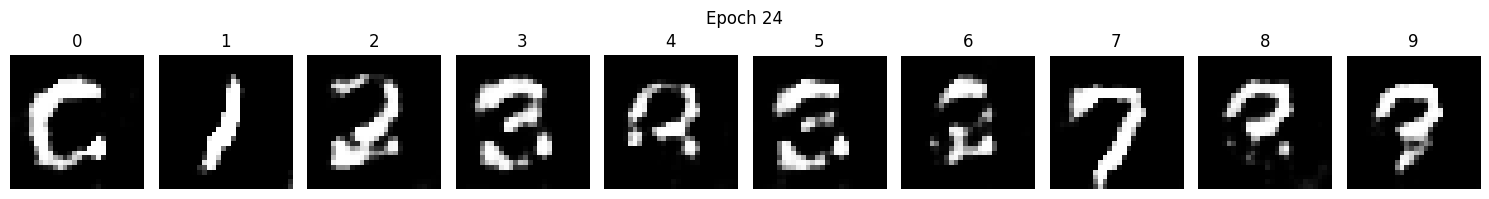

Epoch 24/100  |  D_real 0.678  D_fake 0.696  G 0.693


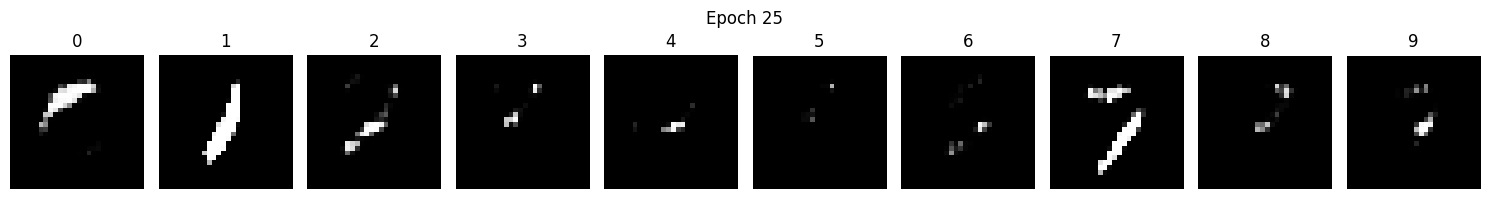

Epoch 25/100  |  D_real 0.660  D_fake 0.710  G 0.694


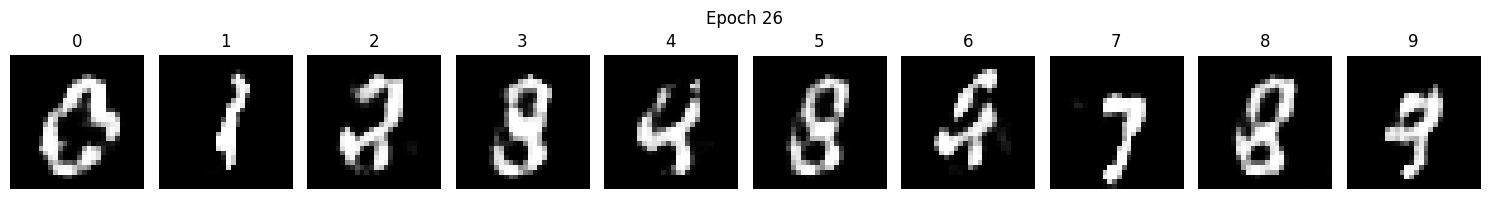

Epoch 26/100  |  D_real 0.693  D_fake 0.672  G 0.694


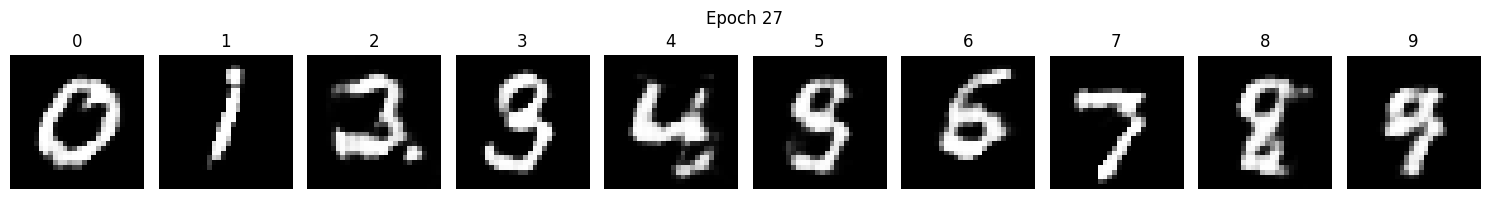

Epoch 27/100  |  D_real 0.683  D_fake 0.712  G 0.693


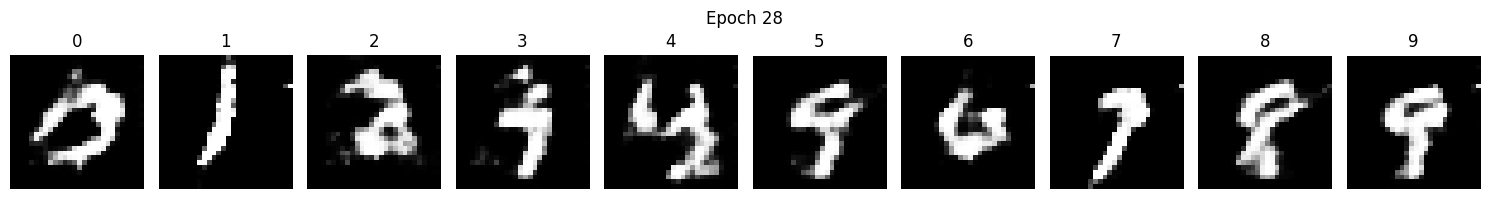

Epoch 28/100  |  D_real 0.683  D_fake 0.691  G 0.693


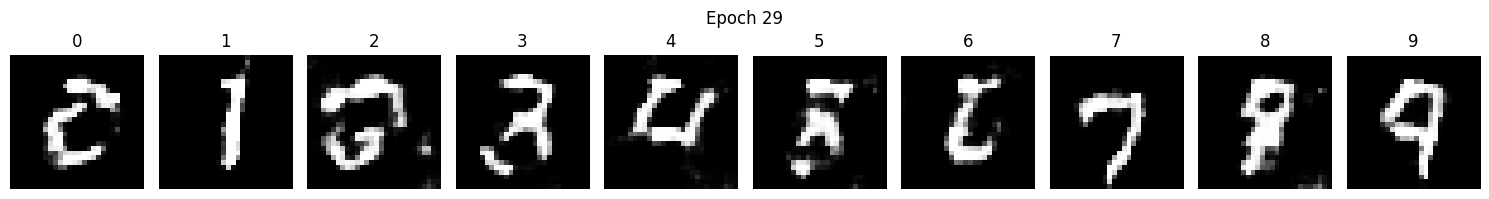

Epoch 29/100  |  D_real 0.696  D_fake 0.688  G 0.693


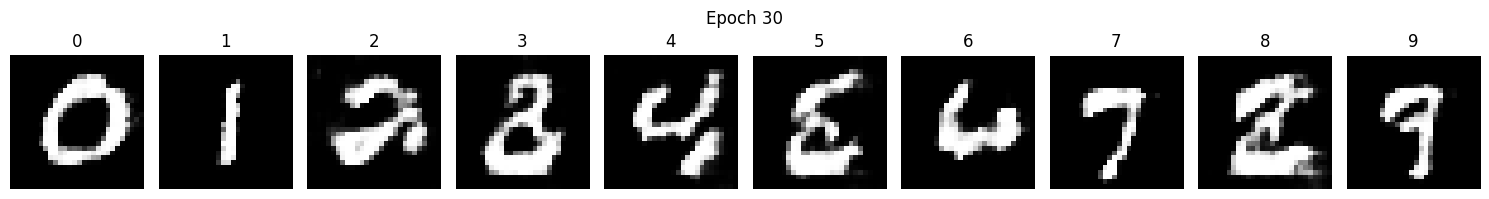

Epoch 30/100  |  D_real 0.698  D_fake 0.692  G 0.693


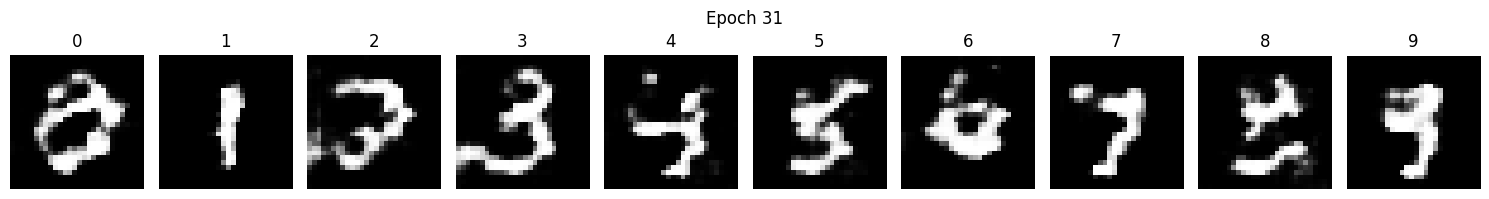

Epoch 31/100  |  D_real 0.691  D_fake 0.693  G 0.693


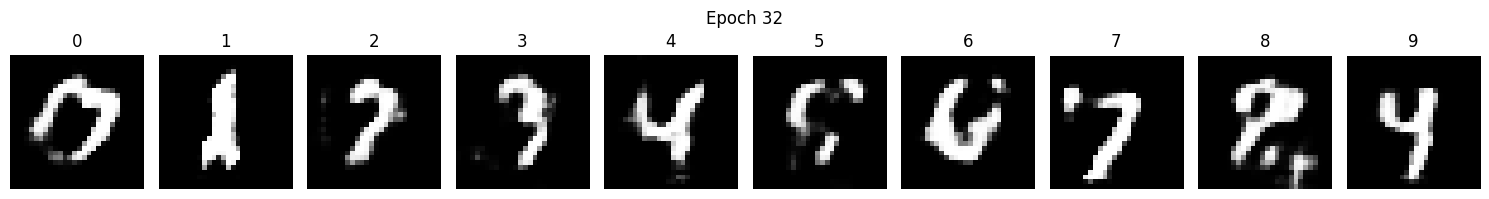

Epoch 32/100  |  D_real 0.680  D_fake 0.660  G 0.693


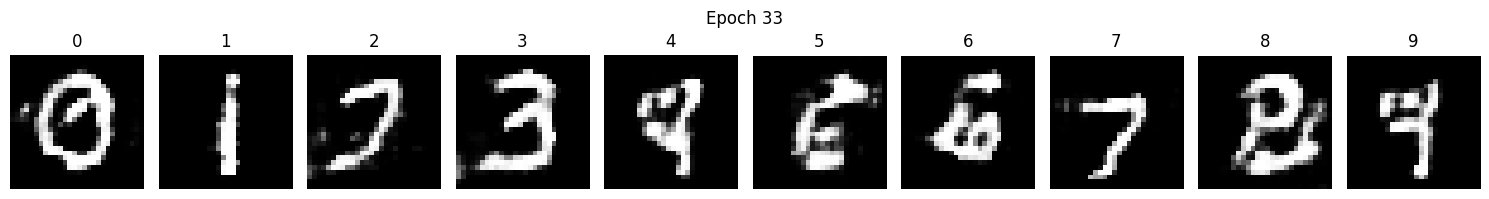

Epoch 33/100  |  D_real 0.680  D_fake 0.707  G 0.693


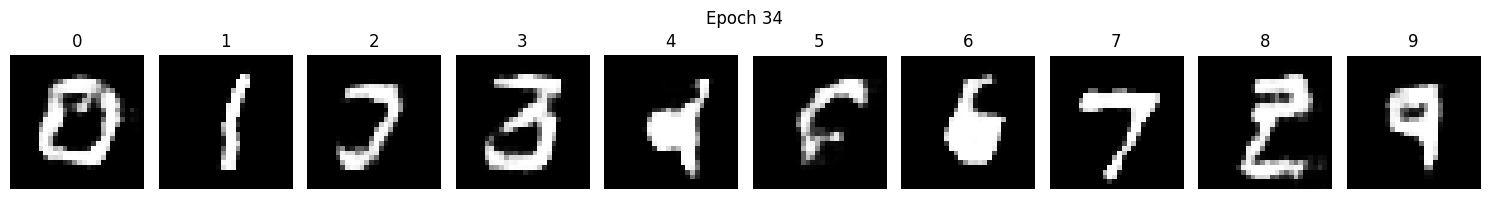

Epoch 34/100  |  D_real 0.677  D_fake 0.719  G 0.693


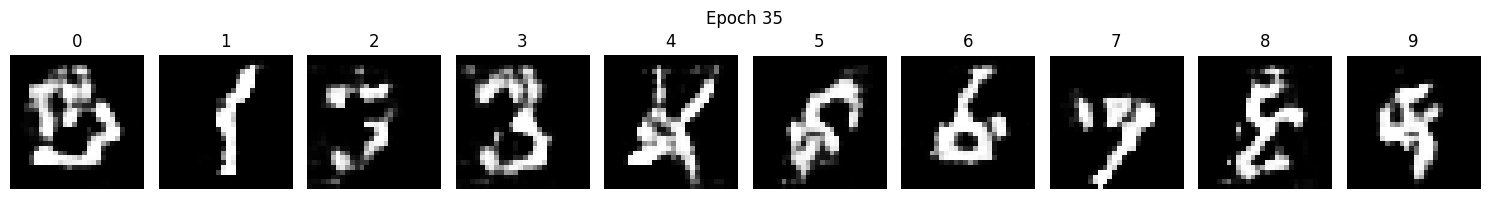

Epoch 35/100  |  D_real 0.686  D_fake 0.680  G 0.693


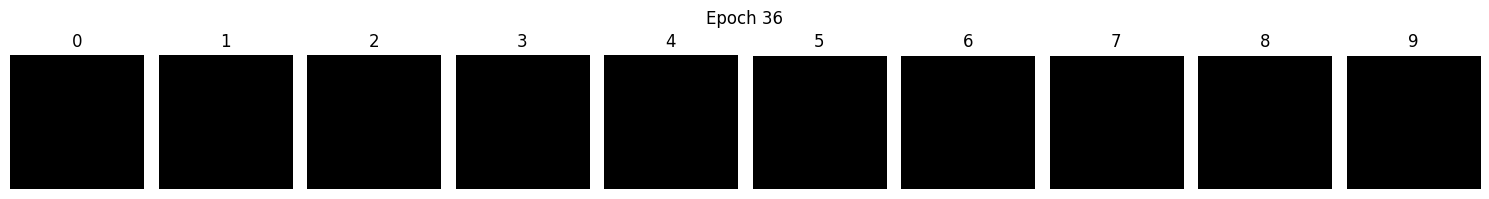

Epoch 36/100  |  D_real 0.245  D_fake 0.142  G 0.702


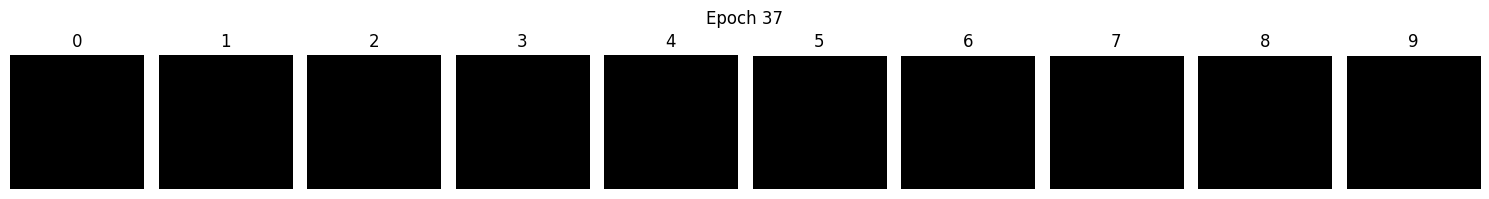

Epoch 37/100  |  D_real 0.037  D_fake 0.023  G 0.769


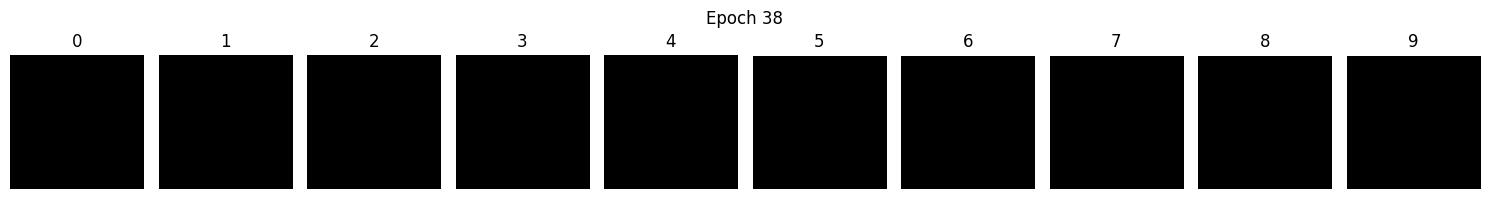

Epoch 38/100  |  D_real 0.007  D_fake 0.008  G 0.871


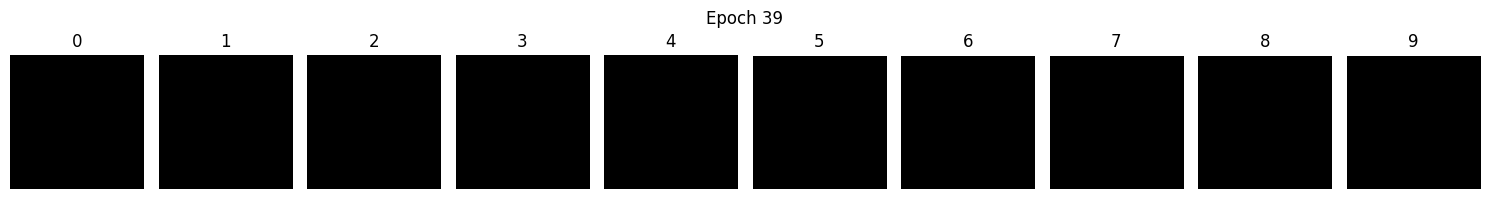

Epoch 39/100  |  D_real 0.006  D_fake 0.003  G 0.991
G_loss spike detected, stopping


In [102]:
n_epochs = 100
batch_size = 128
half_batch = batch_size // 2
batches_per_epoch = dataset[0].shape[0] // batch_size

for epoch in range(n_epochs):
  for _ in range(batches_per_epoch):

    # Make sure discriminator can learn!
    discriminator.trainable = True

    # --- Train Discriminator --- on a half batch of real images
    [X_real, y_real_labels], y_real = get_real_samples(dataset, half_batch)

    # Note: this is just a way to ensure the loss values from 'train_on_batch' get
    # updated properly between the two batches; train_on_batch() won't adjust its loss value
    # output unless you forcefully reset its metrics, something that the regular fit() function
    # does internally.
    discriminator.reset_metrics()
    d_loss_real, _ = discriminator.train_on_batch([X_real, y_real_labels], y_real)

    # --- Train Discriminator --- on a half batch of generated images
    [X_fake, y_fake_labels], y_fake = get_fake_samples(generator, half_batch)
    discriminator.reset_metrics()
    d_loss_fake, _ = discriminator.train_on_batch([X_fake, y_fake_labels], y_fake)

    # --- Train Generator (via the GAN, with the discriminator frozen) ---
    discriminator.trainable = False

    noise = np.random.randn(batch_size, LATENT_DIM)
    labels = np.random.randint(0, 10, batch_size)

    # we want the generator to fool the discriminator
    # So, we are going to pass it labels of 1, and the backprop will try to adjust the generator's
    # weights such that the discriminator is more likely to predict 'real' on these images next time.
    y_trick = np.ones((batch_size, 1))
    g_loss = gan.train_on_batch([noise, labels], y_trick)

  if g_loss > 1.0:
      print("G_loss spike detected, stopping")
      break

  fig, axes = plt.subplots(1, 10, figsize=(15, 2))
  for d in range(10):
    sample = generator.predict([np.random.randn(1, LATENT_DIM), np.array([d])], verbose=0)
    img = (sample[0, :, :, 0] + 1) / 2
    axes[d].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[d].set_title(str(d))
    axes[d].axis('off')
  plt.suptitle(f"Epoch {epoch+1}")
  plt.tight_layout()
  plt.show()

  print(f"Epoch {epoch+1}/{n_epochs}  |  D_real {d_loss_real:.3f}  D_fake {d_loss_fake:.3f}  G {g_loss:.3f}")

# *Generate a Synthetic Digit*

In [ ]:
# Generate one synthetic digit
noise = np.random.randn(1, LATENT_DIM)
label = np.array([7])  # change this to generate a different digit (0-9)

synthetic_img = generator.predict([noise, label], verbose=0)
plt.imshow(synthetic_img[0, :, :, 0], cmap='gray')
plt.title(f"Generated digit: {label[0]}")
plt.axis('off')
plt.show()